In [37]:
import matplotlib.pyplot as plt
from obspy import read, UTCDateTime
from obspy.io.xseed import Parser
from obspy.signal import PPSD
from obspy import read_inventory

In [38]:
st = read(".\SESI 1 - IA.STMKG.SHZ (2025-05-03 10-47-38 - 2025-05-03 10-58-43).mseed")

In [39]:
print(st)

1 Trace(s) in Stream:
IA.STMKG.00.SHZ | 2025-05-03T10:47:38.000000Z - 2025-05-03T10:58:34.980000Z | 50.0 Hz, 32850 samples


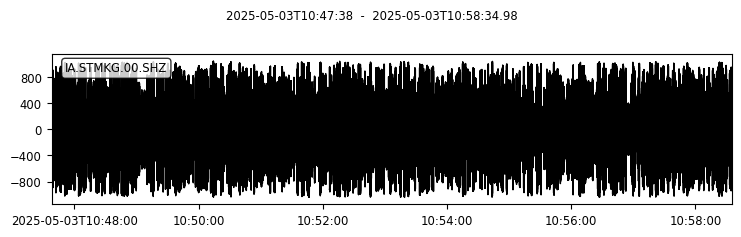

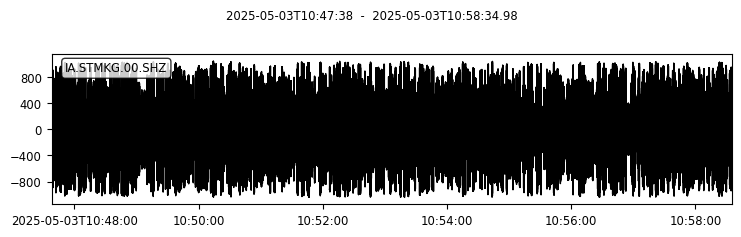

In [40]:
st.plot()

In [41]:
#Path to the XML file
xml_file_path = "stationXML\IA.STMKG12.xml"

# Try reading the station metadata from the XML file
try:
    inv = read_inventory(xml_file_path)
    print("Successfully read inventory.")
    print(inv)
except Exception as e:
    print(f"Error reading inventory: {e}")


Successfully read inventory.
Inventory created at 2025-05-23T14:59:32.228358Z
	Sending institution: scxml import (ObsPy Inventory)
	Contains:
		Networks (1):
			IA
		Stations (1):
			IA.STMKG (Tanah Tinggi)
		Channels (1):
			IA.STMKG.00.SHZ


In [42]:
st.attach_response(inv)

[]

In [43]:
tr = st.select(id="IA.STMKG.00.SHZ")[0]

In [44]:
print(tr.id)
print(tr.stats)


IA.STMKG.00.SHZ
         network: IA
         station: STMKG
        location: 00
         channel: SHZ
       starttime: 2025-05-03T10:47:38.000000Z
         endtime: 2025-05-03T10:58:34.980000Z
   sampling_rate: 50.0
           delta: 0.02
            npts: 32850
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 66, 'encoding': 'FLOAT64', 'byteorder': '>', 'record_length': 4096, 'filesize': 270336})
        response: Channel Response
	From V/m/s () to None ()
	Overall Sensitivity: 9.66368e+07 defined at 4.500 Hz
	3 stages:
		Stage 1: PolesZerosResponseStage from V/m/s to V, gain: 28.8
		Stage 2: CoefficientsTypeResponseStage from V to COUNTS, gain: 3.35544e+06
		Stage 3: FIRResponseStage from COUNTS to COUNTS, gain: 1


In [45]:
ppsd = PPSD(tr.stats, metadata=inv, ppsd_length=600)

In [46]:
ppsd.add(tr)

c:\Users\raiha\AppData\Local\Programs\Python\Python310\lib\site-packages\obspy\core\inventory\response.py:1230: UserWarning: The unit 'V/M/S' is not known to ObsPy. It will be passed in to evalresp as 'undefined'. This should result in evalresp using the response as is, without adding any integration or differentiation and the 'output' parameter (here: 'VEL') not having any effect. Please double check output data.
  warnings.warn(msg)


True

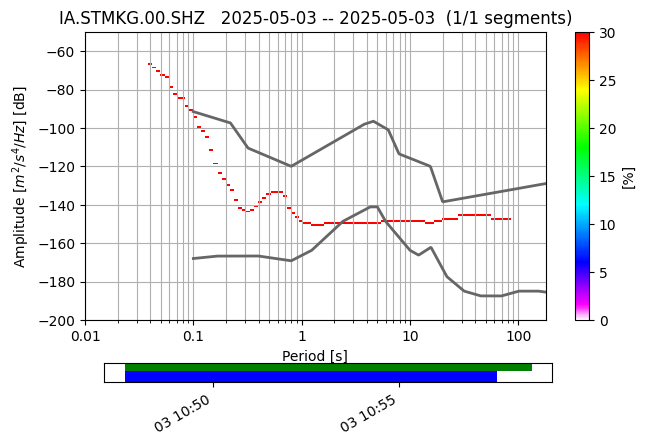

In [47]:
from obspy.imaging.cm import pqlx
ppsd.plot(cmap=pqlx)